# OPRA EQ dataset extraction

Ноутбук для выгрузки датасета **OPRA EQ-профилей** в единый промежуточный файл.

Ожидаемая структура:

```text
mapper_v2/
  external_data/
    opra/
  outputs/
```

Результат:

```text
outputs/opra_eq_profiles.parquet
outputs/opra_eq_profiles.csv
```

Этот ноутбук не обучает mapper. Он только скачивает/читает OPRA, ищет EQ-профили, переводит их в `curve_23` и сохраняет готовую таблицу для следующего ноутбука, где мы уже будем строить 8D-пространство.


In [1]:
from pathlib import Path
import re
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import yaml
    HAS_YAML = True
except ImportError:
    HAS_YAML = False


DATA_ROOT = Path("external_data")
OPRA_DIR = DATA_ROOT / "opra"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_FILE_PARQUET = OUTPUT_DIR / "opra_eq_profiles.parquet"
OUTPUT_FILE_CSV = OUTPUT_DIR / "opra_eq_profiles.csv"


# ==== Frequency grid ====

SOCIALFX_FILE = Path("outputs/socialfx_curves_with_6d.parquet")

if SOCIALFX_FILE.exists():
    df_socialfx_preview = pd.read_parquet(SOCIALFX_FILE)

    if "freqs_23" in df_socialfx_preview.columns:
        freqs_23 = np.asarray(df_socialfx_preview.iloc[0]["freqs_23"], dtype=float)
        print("Loaded freqs_23 from:", SOCIALFX_FILE)
    else:
        raise ValueError("Column freqs_23 not found in socialfx file.")
else:
    freqs_23 = np.array(
        [
            20, 50, 83, 120, 160, 200, 276, 383, 440, 500,
            622, 776, 1000, 1500, 2000, 2400, 3500, 4400,
            6900, 9000, 12000, 14000, 16000,
        ],
        dtype=float,
    )
    print("Using fallback freqs_23.")

print("freqs_23:", freqs_23)
print("min/max:", freqs_23.min(), freqs_23.max())
print("num bands:", len(freqs_23))

Loaded freqs_23 from: outputs\socialfx_curves_with_6d.parquet
freqs_23: [   20.            50.            83.           120.
   159.51029968   200.04376221   254.04821777   308.56271362
   383.           443.86398315   622.04351807   798.06713867
  1000.          1485.98254395  1875.          2368.08081055
  3389.64819336  4365.36328125  6934.26074219  8568.99511719
 12000.         14000.         16000.        ]
min/max: 20.0 16000.0
num bands: 23


In [2]:
# ==== Download OPRA dataset ====

from pathlib import Path
import subprocess

DATA_ROOT = Path("external_data")
DATA_ROOT.mkdir(exist_ok=True)

OPRA_DIR = DATA_ROOT / "opra"

if OPRA_DIR.exists():
    print("OPRA already exists:", OPRA_DIR.resolve())
else:
    subprocess.run(
        ["git", "clone", "https://github.com/opra-project/opra.git", str(OPRA_DIR)],
        check=True,
    )
    print("Downloaded OPRA to:", OPRA_DIR.resolve())

OPRA already exists: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\external_data\opra


In [3]:
# ==== Inspect dataset directory ====

if not OPRA_DIR.exists():
    print(f"Directory not found: {OPRA_DIR}")
    print("Put the dataset into external_data/opra or change OPRA_DIR.")
else:
    all_files = [p for p in OPRA_DIR.rglob("*") if p.is_file()]
    print("Total files:", len(all_files))

    ext_counts = pd.Series([p.suffix.lower() or "<no_ext>" for p in all_files]).value_counts()
    display(ext_counts.head(30))

    display(pd.DataFrame({
        "path": [str(p.relative_to(OPRA_DIR)) for p in all_files[:80]],
        "suffix": [p.suffix.lower() for p in all_files[:80]],
        "size_kb": [round(p.stat().st_size / 1024, 2) for p in all_files[:80]],
    }))


Total files: 20478


.json       19538
.png          554
.svg          318
.ts            21
.sample        14
<no_ext>       12
.md             8
.yml            3
.pdf            2
.txt            2
.idx            1
.pack           1
.rev            1
.jsonl          1
.toml           1
.js             1
Name: count, dtype: int64

,path,suffix,size_kb
0,.gitignore,,0.22
1,CLAUDE.md,.md,2.66
2,deno.json,.json,1.16
3,LICENSE.md,.md,21.04
4,README.md,.md,6.66
...,...,...,...
75,database\vendors\1more\products\fit_se_s30\lin...,.svg,3.29
76,database\vendors\1more\products\fit_se_s30\eq\...,.json,1.33
77,database\vendors\1more\products\h1701_triple_d...,.json,0.10
78,database\vendors\1more\products\h1701_triple_d...,.json,1.42


## 2. Рендеринг EQ-фильтров в `curve_23`

Поддерживаются:

- Parametric peak: `PK`, `PEAK`, `PEAKING`, `PEQ`, `BELL`
- Low shelf: `LS`, `LOWSHELF`
- High shelf: `HS`, `HIGHSHELF`
- Graphic EQ / freq-gain points через log-frequency interpolation


In [4]:
# ==== EQ rendering helpers ====

def biquad_response_db(freqs, filter_type, fc, gain_db, q=1.0, fs=48000.0):
    freqs = np.asarray(freqs, dtype=float)
    filter_type = str(filter_type).lower().replace(" ", "").replace("_", "")

    fc = float(fc)
    gain_db = float(gain_db)
    q = float(q) if q is not None else 1.0

    fc = np.clip(fc, 1.0, fs / 2.0 - 1.0)
    q = max(q, 1e-4)

    A = 10 ** (gain_db / 40.0)
    w0 = 2 * np.pi * fc / fs
    alpha = np.sin(w0) / (2 * q)
    cosw0 = np.cos(w0)

    if filter_type in ["pk", "peak", "peaking", "peq", "bell"]:
        b0 = 1 + alpha * A
        b1 = -2 * cosw0
        b2 = 1 - alpha * A
        a0 = 1 + alpha / A
        a1 = -2 * cosw0
        a2 = 1 - alpha / A

    elif filter_type in ["ls", "lowshelf", "lowshelving"]:
        sqrtA = np.sqrt(A)
        b0 = A * ((A + 1) - (A - 1) * cosw0 + 2 * sqrtA * alpha)
        b1 = 2 * A * ((A - 1) - (A + 1) * cosw0)
        b2 = A * ((A + 1) - (A - 1) * cosw0 - 2 * sqrtA * alpha)
        a0 = (A + 1) + (A - 1) * cosw0 + 2 * sqrtA * alpha
        a1 = -2 * ((A - 1) + (A + 1) * cosw0)
        a2 = (A + 1) + (A - 1) * cosw0 - 2 * sqrtA * alpha

    elif filter_type in ["hs", "highshelf", "highshelving"]:
        sqrtA = np.sqrt(A)
        b0 = A * ((A + 1) + (A - 1) * cosw0 + 2 * sqrtA * alpha)
        b1 = -2 * A * ((A - 1) + (A + 1) * cosw0)
        b2 = A * ((A + 1) + (A - 1) * cosw0 - 2 * sqrtA * alpha)
        a0 = (A + 1) - (A - 1) * cosw0 + 2 * sqrtA * alpha
        a1 = 2 * ((A - 1) - (A + 1) * cosw0)
        a2 = (A + 1) - (A - 1) * cosw0 - 2 * sqrtA * alpha

    else:
        return np.zeros_like(freqs, dtype=float)

    b = np.array([b0, b1, b2], dtype=complex) / a0
    a = np.array([1.0, a1 / a0, a2 / a0], dtype=complex)

    w = 2 * np.pi * freqs / fs
    z1 = np.exp(-1j * w)
    z2 = np.exp(-2j * w)

    h = (b[0] + b[1] * z1 + b[2] * z2) / (a[0] + a[1] * z1 + a[2] * z2)
    return 20 * np.log10(np.maximum(np.abs(h), 1e-12)).real


def render_parametric_filters(filters, freqs=freqs_23, fs=48000.0):
    curve = np.zeros_like(freqs, dtype=float)

    for filt in filters:
        ftype = filt.get("type") or filt.get("filter_type") or filt.get("kind") or filt.get("shape") or "PK"
        fc = filt.get("freq") or filt.get("frequency") or filt.get("fc") or filt.get("f")
        gain = filt.get("gain") or filt.get("gain_db") or filt.get("db") or filt.get("gainDB") or 0.0
        q = filt.get("q") or filt.get("Q") or filt.get("quality") or 1.0

        if fc is None:
            continue

        try:
            curve += biquad_response_db(freqs, ftype, fc, gain, q=q, fs=fs)
        except Exception:
            pass

    return curve


def interpolate_graphic_eq(points, freqs=freqs_23):
    if len(points) < 2:
        return None

    pts = np.asarray(points, dtype=float)
    pts = pts[np.argsort(pts[:, 0])]

    x = np.log10(pts[:, 0])
    y = pts[:, 1]
    target_x = np.log10(freqs)

    return np.interp(target_x, x, y)


## 3. Парсеры

Поддерживаем несколько популярных вариантов:

```text
GraphicEQ: 20 0.0; 25 -1.2; ...
Filter 1: ON PK Fc 105 Hz Gain -3 dB Q 0.7
CSV: frequency, gain, q, type
JSON/YAML: вложенные словари со freq/gain/q/type
```


In [5]:
# ==== Text parser ====

GRAPHIC_EQ_RE = re.compile(
    r"GraphicEQ\s*:\s*(.+)",
    flags=re.IGNORECASE | re.DOTALL,
)

APO_FILTER_RE = re.compile(
    r"Filter\s+\d+\s*:\s*ON\s+"
    r"(?P<type>[A-Za-z0-9_]+)\s+"
    r"Fc\s+(?P<freq>[-+]?\d*\.?\d+)\s*Hz\s+"
    r"Gain\s+(?P<gain>[-+]?\d*\.?\d+)\s*dB\s+"
    r"Q\s+(?P<q>[-+]?\d*\.?\d+)",
    flags=re.IGNORECASE,
)


def parse_graphic_eq_from_text(text):
    match = GRAPHIC_EQ_RE.search(text)
    if not match:
        return None

    body = match.group(1)
    chunks = re.split(r"[;\n]+", body)
    pairs = []

    for chunk in chunks:
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", chunk)
        if len(nums) >= 2:
            try:
                freq = float(nums[0])
                gain = float(nums[1])
                if 5 <= freq <= 50000 and -80 <= gain <= 80:
                    pairs.append((freq, gain))
            except ValueError:
                pass

    if len(pairs) < 2:
        return None

    return pairs


def parse_apo_filters_from_text(text):
    filters = []

    for match in APO_FILTER_RE.finditer(text):
        try:
            filters.append({
                "type": match.group("type"),
                "freq": float(match.group("freq")),
                "gain": float(match.group("gain")),
                "q": float(match.group("q")),
            })
        except ValueError:
            pass

    return filters


def parse_plain_freq_gain_table(text):
    points = []

    for line in text.splitlines():
        line = line.strip()

        if not line or line.startswith("#") or line.startswith("//"):
            continue

        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", line)

        if len(nums) >= 2:
            try:
                freq = float(nums[0])
                gain = float(nums[1])

                if 5 <= freq <= 50000 and -80 <= gain <= 80:
                    points.append((freq, gain))
            except ValueError:
                pass

    if len(points) < 2:
        return None

    unique_freqs = len(set(round(p[0], 3) for p in points))
    if unique_freqs < 2:
        return None

    return points


def parse_text_profile(path):
    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return None

    points = parse_graphic_eq_from_text(text)
    if points is not None:
        return {
            "profile_type": "graphic_eq_text",
            "curve_23": interpolate_graphic_eq(points, freqs_23),
            "num_points": len(points),
            "num_filters": 0,
        }

    filters = parse_apo_filters_from_text(text)
    if len(filters) > 0:
        return {
            "profile_type": "apo_parametric_text",
            "curve_23": render_parametric_filters(filters, freqs_23),
            "num_points": 0,
            "num_filters": len(filters),
        }

    points = parse_plain_freq_gain_table(text)
    if points is not None:
        return {
            "profile_type": "freq_gain_table_text",
            "curve_23": interpolate_graphic_eq(points, freqs_23),
            "num_points": len(points),
            "num_filters": 0,
        }

    return None


In [6]:
# ==== JSON / YAML / CSV parser ====

def flatten_dict_like(obj):
    stack = [obj]

    while stack:
        cur = stack.pop()
        yield cur

        if isinstance(cur, dict):
            stack.extend(cur.values())
        elif isinstance(cur, list):
            stack.extend(cur)


def looks_like_filter_dict(d):
    if not isinstance(d, dict):
        return False

    keys = {str(k).lower() for k in d.keys()}
    has_freq = bool(keys & {"freq", "frequency", "fc", "f"})
    has_gain = bool(keys & {"gain", "gain_db", "gaindb", "db"})
    has_q = bool(keys & {"q", "quality"})
    has_type = bool(keys & {"type", "filter_type", "kind", "shape"})

    return has_freq and has_gain and (has_q or has_type)


def normalize_filter_dict(d):
    out = {}

    for k, v in d.items():
        lk = str(k).lower()

        if lk in ["freq", "frequency", "fc", "f"]:
            out["freq"] = v
        elif lk in ["gain", "gain_db", "gaindb", "db"]:
            out["gain"] = v
        elif lk in ["q", "quality"]:
            out["q"] = v
        elif lk in ["type", "filter_type", "kind", "shape"]:
            out["type"] = v

    out.setdefault("type", "PK")
    out.setdefault("q", 1.0)

    return out


def extract_filters_from_obj(obj):
    filters = []

    for node in flatten_dict_like(obj):
        if looks_like_filter_dict(node):
            filters.append(normalize_filter_dict(node))

    return filters


def parse_json_or_yaml_profile(path):
    suffix = path.suffix.lower()

    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
    except Exception:
        return None

    try:
        if suffix == ".json":
            obj = json.loads(text)
        elif suffix in [".yaml", ".yml"] and HAS_YAML:
            obj = yaml.safe_load(text)
        else:
            return None
    except Exception:
        return None

    filters = extract_filters_from_obj(obj)

    if len(filters) == 0:
        return None

    return {
        "profile_type": f"{suffix[1:]}_parametric",
        "curve_23": render_parametric_filters(filters, freqs_23),
        "num_points": 0,
        "num_filters": len(filters),
    }


def parse_csv_profile(path):
    try:
        df = pd.read_csv(path)
    except Exception:
        return None

    columns_lower = {c.lower(): c for c in df.columns}

    freq_col = None
    gain_col = None

    for candidate in ["freq", "frequency", "fc", "f", "hz"]:
        if candidate in columns_lower:
            freq_col = columns_lower[candidate]
            break

    for candidate in ["gain", "gain_db", "gaindb", "db"]:
        if candidate in columns_lower:
            gain_col = columns_lower[candidate]
            break

    if freq_col is None or gain_col is None:
        return None

    q_col = None
    type_col = None

    for candidate in ["q", "quality"]:
        if candidate in columns_lower:
            q_col = columns_lower[candidate]
            break

    for candidate in ["type", "filter_type", "kind", "shape"]:
        if candidate in columns_lower:
            type_col = columns_lower[candidate]
            break

    if q_col is not None or type_col is not None:
        filters = []

        for _, row in df.iterrows():
            try:
                filters.append({
                    "type": row[type_col] if type_col is not None else "PK",
                    "freq": float(row[freq_col]),
                    "gain": float(row[gain_col]),
                    "q": float(row[q_col]) if q_col is not None and not pd.isna(row[q_col]) else 1.0,
                })
            except Exception:
                pass

        if len(filters) > 0:
            return {
                "profile_type": "csv_parametric",
                "curve_23": render_parametric_filters(filters, freqs_23),
                "num_points": 0,
                "num_filters": len(filters),
            }

    points = []

    for _, row in df.iterrows():
        try:
            freq = float(row[freq_col])
            gain = float(row[gain_col])

            if 5 <= freq <= 50000 and -80 <= gain <= 80:
                points.append((freq, gain))
        except Exception:
            pass

    if len(points) >= 2:
        return {
            "profile_type": "csv_graphic",
            "curve_23": interpolate_graphic_eq(points, freqs_23),
            "num_points": len(points),
            "num_filters": 0,
        }

    return None


def parse_profile_file(path):
    suffix = path.suffix.lower()

    if suffix in [".txt", ".peace", ".apo", ".eq", ".cfg", ".conf", ".md"]:
        return parse_text_profile(path)

    if suffix in [".json", ".yaml", ".yml"]:
        parsed = parse_json_or_yaml_profile(path)
        if parsed is not None:
            return parsed
        return parse_text_profile(path)

    if suffix == ".csv":
        parsed = parse_csv_profile(path)
        if parsed is not None:
            return parsed
        return parse_text_profile(path)

    if suffix in ["", ".dat"]:
        return parse_text_profile(path)

    return None


## 4. Выгрузка профилей

На выходе получаем `df_external`, где каждая строка — один EQ-профиль, приведённый к `curve_23`.


In [7]:
# ==== Extract profiles ====

def extract_profiles_from_dataset(root_dir, source_dataset="opra", max_files=None):
    root_dir = Path(root_dir)

    if not root_dir.exists():
        raise FileNotFoundError(f"Dataset directory not found: {root_dir}")

    files = [p for p in root_dir.rglob("*") if p.is_file()]

    if max_files is not None:
        files = files[:max_files]

    rows = []
    failed = []

    for path in files:
        parsed = parse_profile_file(path)

        if parsed is None:
            failed.append(path)
            continue

        curve = np.asarray(parsed["curve_23"], dtype=float)

        if curve.shape != freqs_23.shape:
            failed.append(path)
            continue

        if not np.all(np.isfinite(curve)):
            failed.append(path)
            continue

        rows.append({
            "source_dataset": source_dataset,
            "relative_path": str(path.relative_to(root_dir)),
            "filename": path.name,
            "suffix": path.suffix.lower(),
            "profile_type": parsed["profile_type"],
            "num_points": parsed["num_points"],
            "num_filters": parsed["num_filters"],
            "curve_23": curve.astype(np.float32),
            "gain_min": float(np.min(curve)),
            "gain_max": float(np.max(curve)),
            "gain_abs_max": float(np.max(np.abs(curve))),
            "gain_mean": float(np.mean(curve)),
            "gain_std": float(np.std(curve)),
        })

    return pd.DataFrame(rows), failed


df_external, failed_files = extract_profiles_from_dataset(
    OPRA_DIR,
    source_dataset="opra",
    max_files=None,
)

print("Parsed profiles:", len(df_external))
print("Failed/unparsed files:", len(failed_files))

if len(df_external) > 0:
    display(df_external.head())
    display(df_external["profile_type"].value_counts())
else:
    print("No profiles parsed. Inspect file examples below.")


Parsed profiles: 12595
Failed/unparsed files: 7883


,source_dataset,relative_path,filename,suffix,profile_type,num_points,num_filters,curve_23,gain_min,gain_max,gain_abs_max,gain_mean,gain_std
0,opra,.git\index,index,,freq_gain_table_text,13814,0,"[20.0, 2.0, 5.0, 46.0, 7.70443, 4.8900604, 1.0...",1.000000,46.000000,46.000000,6.070126,9.389348
1,opra,database\vendors\1custom\products\sa02\eq\auto...,info.json,.json,json_parametric,0,10,"[5.4881635, 5.1938915, 3.9035857, 2.0669541, 0...",-1.055203,5.488164,5.488164,0.651244,1.754718
2,opra,database\vendors\1custom\products\sa03\eq\auto...,info.json,.json,json_parametric,0,10,"[2.3950322, 2.271908, 1.7140299, 0.8947236, 0....",-1.822291,2.395032,2.395032,0.093198,1.004214
3,opra,database\vendors\1custom\products\sa05\eq\auto...,info.json,.json,json_parametric,0,10,"[2.8939717, 2.7445095, 2.0696988, 1.0820913, 0...",-2.397266,2.893972,2.893972,0.085348,1.256230
4,opra,database\vendors\1more\products\1m301_single_d...,info.json,.json,json_parametric,0,7,"[9.9893465, 9.523152, 7.374416, 4.215076, 2.02...",0.000483,9.989346,9.989346,1.681013,2.993014


profile_type
json_parametric         12590
freq_gain_table_text        4
apo_parametric_text         1
Name: count, dtype: int64

## 5. Sanity-check

Смотрим диапазоны gain, случайные кривые и среднюю кривую.


,gain_min,gain_max,gain_abs_max,gain_mean,gain_std
count,1.259500e+04,12595.000000,12595.000000,12595.000000,12595.000000
mean,-2.732260e+00,3.718995,5.310709,0.189980,1.776501
std,2.860927e+00,3.443140,2.963477,1.003810,0.978662
min,-3.000000e+01,-0.349571,0.000000,-13.832571,0.000000
25%,-4.405896e+00,0.199590,3.193329,-0.433960,1.078737
50%,-2.095663e+00,3.362659,5.359435,0.168400,1.736116
75%,3.570283e-07,6.086727,6.784807,0.794368,2.312023
max,9.877413e+00,64.000000,64.000000,12.864235,22.272961


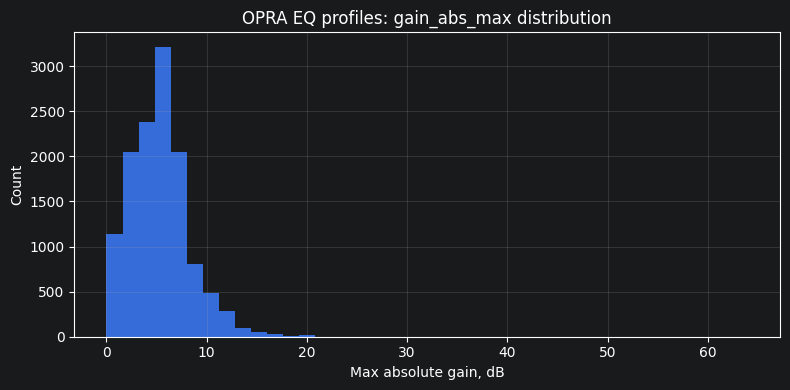

In [8]:
# ==== Dataset summary ====

if len(df_external) > 0:
    display(df_external[
        ["gain_min", "gain_max", "gain_abs_max", "gain_mean", "gain_std"]
    ].describe())

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_external["gain_abs_max"], bins=40)
    ax.set_xlabel("Max absolute gain, dB")
    ax.set_ylabel("Count")
    ax.set_title("OPRA EQ profiles: gain_abs_max distribution")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


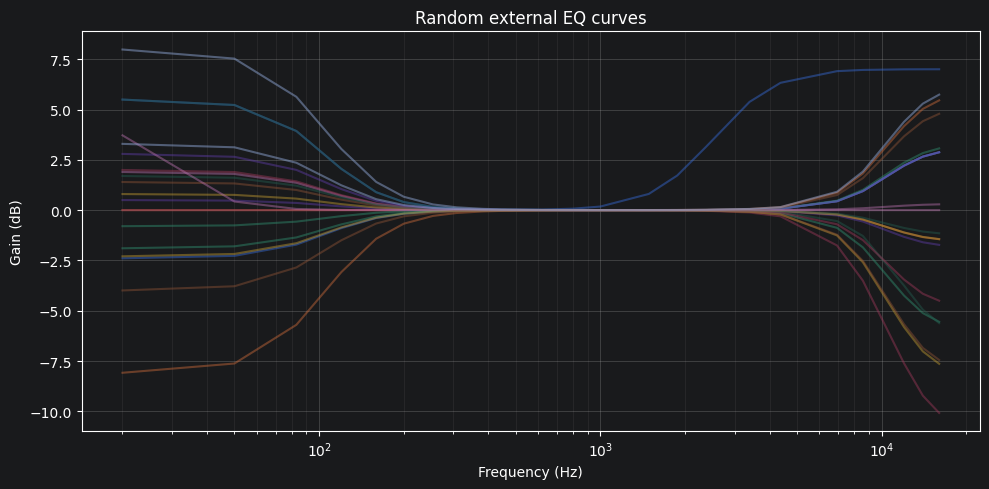

In [9]:
# ==== Random curves ====

if len(df_external) > 0:
    sample_df = df_external.sample(min(20, len(df_external)), random_state=42)

    fig, ax = plt.subplots(figsize=(10, 5))

    for _, row in sample_df.iterrows():
        ax.plot(freqs_23, row["curve_23"], alpha=0.45)

    ax.set_xscale("log")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (dB)")
    ax.set_title("Random external EQ curves")
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)
    plt.tight_layout()
    plt.show()


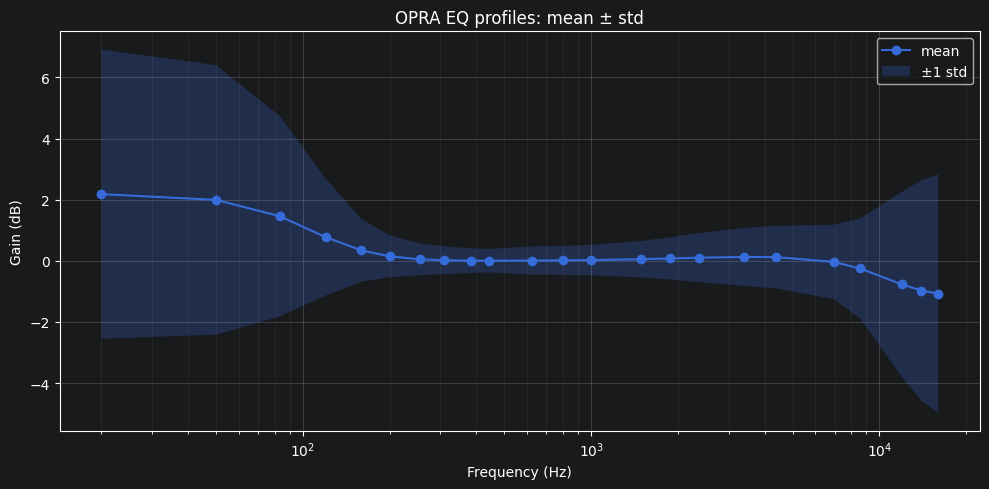

In [10]:
# ==== Mean ± std curve ====

if len(df_external) > 0:
    curves = np.stack(df_external["curve_23"].values)

    mean_curve = curves.mean(axis=0)
    std_curve = curves.std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(freqs_23, mean_curve, marker="o", label="mean")
    ax.fill_between(freqs_23, mean_curve - std_curve, mean_curve + std_curve, alpha=0.25, label="±1 std")

    ax.set_xscale("log")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (dB)")
    ax.set_title("OPRA EQ profiles: mean ± std")
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.12)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 7. Фильтрация

На первом этапе убираем подозрительно экстремальные профили.

Порог можно менять. Стартовое значение:

```text
gain_abs_max <= 24 dB
```


In [11]:
# ==== Filter suspicious profiles ====

MAX_ABS_GAIN_DB = 24.0

if len(df_external) > 0:
    before = len(df_external)

    df_external_clean = df_external[
        df_external["gain_abs_max"] <= MAX_ABS_GAIN_DB
    ].copy()

    after = len(df_external_clean)

    print("Before:", before)
    print("After: ", after)
    print("Removed:", before - after)

    display(df_external_clean.head())
else:
    df_external_clean = df_external.copy()


Before: 12595
After:  12593
Removed: 2


,source_dataset,relative_path,filename,suffix,profile_type,num_points,num_filters,curve_23,gain_min,gain_max,gain_abs_max,gain_mean,gain_std
1,opra,database\vendors\1custom\products\sa02\eq\auto...,info.json,.json,json_parametric,0,10,"[5.4881635, 5.1938915, 3.9035857, 2.0669541, 0...",-1.055203,5.488164,5.488164,0.651244,1.754718
2,opra,database\vendors\1custom\products\sa03\eq\auto...,info.json,.json,json_parametric,0,10,"[2.3950322, 2.271908, 1.7140299, 0.8947236, 0....",-1.822291,2.395032,2.395032,0.093198,1.004214
3,opra,database\vendors\1custom\products\sa05\eq\auto...,info.json,.json,json_parametric,0,10,"[2.8939717, 2.7445095, 2.0696988, 1.0820913, 0...",-2.397266,2.893972,2.893972,0.085348,1.256230
4,opra,database\vendors\1more\products\1m301_single_d...,info.json,.json,json_parametric,0,7,"[9.9893465, 9.523152, 7.374416, 4.215076, 2.02...",0.000483,9.989346,9.989346,1.681013,2.993014
5,opra,database\vendors\1more\products\aero\eq\autoeq...,info.json,.json,json_parametric,0,10,"[0.09979513, 0.09471751, 0.07152903, 0.0372154...",0.000390,3.641548,3.641548,0.523682,1.100983


## 8. Сохранение

Сохраняем:

```text
outputs/opra_eq_profiles.parquet
outputs/opra_eq_profiles.csv
```

В файле есть:

- метаданные профиля;
- `curve_23_json`;
- отдельные колонки gain по частотам.


In [12]:
# ==== Save extracted dataset ====

def prepare_for_save(df):
    df_save = df.copy()

    df_save["curve_23_json"] = df_save["curve_23"].apply(
        lambda arr: json.dumps([float(x) for x in np.asarray(arr)])
    )

    curves = np.stack(df_save["curve_23"].values) if len(df_save) > 0 else np.empty((0, len(freqs_23)))

    for i, freq in enumerate(freqs_23):
        if freq < 1000:
            col = f"gain_{str(freq).replace('.', '_')}hz"
        else:
            col = f"gain_{str(freq).replace('.', '_')}hz"
        df_save[col] = curves[:, i] if len(df_save) > 0 else []

    df_save = df_save.drop(columns=["curve_23"])

    return df_save


df_save = prepare_for_save(df_external_clean)

if len(df_save) == 0:
    print("No profiles to save.")
else:
    try:
        df_save.to_parquet(OUTPUT_FILE_PARQUET, index=False)
        print("Saved parquet:", OUTPUT_FILE_PARQUET.resolve())
    except Exception as e:
        print("Could not save parquet:", e)

    df_save.to_csv(OUTPUT_FILE_CSV, index=False)
    print("Saved csv:", OUTPUT_FILE_CSV.resolve())

    print("Rows:", len(df_save))
    print("Columns:", len(df_save.columns))


Saved parquet: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\opra_eq_profiles.parquet
Saved csv: C:\Users\makcc\PycharmProjects\EarLoop\research\mapper_v2\outputs\opra_eq_profiles.csv
Rows: 12593
Columns: 36


## 10. Дальше

В следующем ноутбуке:

```python
df_external = load_external_profiles("outputs/opra_eq_profiles.parquet")
curves = np.stack(df_external["curve_23"].values)
```

И дальше уже:

```text
curve_23
  ↓
8D/9D extractor
  ↓
comparison with SocialFX
  ↓
mapper training / augmentation decision
```
